# **Lab Assignment 2**

**Objective**
The main objective of this lab is to train a deep neural network on a real-world dataset and study why deep networks are harder to train than shallow models.

The idea is to build a model architecture which includes - **forward pass, loss calculation, manual parameter updates.**

Then also improve the model performance by experimenting with different **activation functions, mini-batch SGD, momentum, and skip connections, and compare how each technique affects the learning results**.

**Initial Idea**:

* Use the **EuroSAT land-cover dataset** (RGB satellite images) available through `torchvision.datasets.EuroSAT`.
* Apply a consistent preprocessing pipeline: **resize → tensor conversion → normalization** so all models train on the same input distribution.
* Create **one fixed 70/30 train-test split** (seeded) and reuse it across every experiment to ensure results are comparable.
* Start with a **shallow 2-layer MLP (sigmoid)** as a difficulty check and confirm accuracy stays relatively low.
* Build a deeper **CNN + multi-layer fully-connected baseline** and train it using **manual SGD** (no `torch.optim`).
* Improve performance systematically by testing:

  * **activation functions** (sigmoid vs tanh vs leaky ReLU),
  * **mini-batch training** (different batch sizes),
  * **momentum + weight decay** (manual implementation),
  * and a deeper network with **skip connections** to study training stability.
* Track results using **accuracy, macro precision, and macro recall**, and report **epoch-1 gradient magnitudes** to compare training dynamics across deeper architectures.


**Data**: Bosch Traffic Lights Dataset

**Resource Link** : https://zenodo.org/records/12706046?utm_source=chatgpt.com


LAB 2 START — EUROSTAT LAND COVER CLASSIFICATION
Device detected : cpu
Seed            : 42

DELIVERABLE (Part 1): Dataset Selection + Preprocessing + Fixed Split


100%|██████████| 94.3M/94.3M [00:00<00:00, 351MB/s]


Dataset       : torchvision.datasets.EuroSAT
Classes       : 10
Total samples : 27000
Image size    : 64x64
Transforms    : Resize -> ToTensor -> Normalize(mean=0.5,std=0.5)
Split         : 70% train / 30% test (fixed seed split)
Train size : 18900
Test size  : 8100

------------------------------------------------------------------------------
Train class distribution
------------------------------------------------------------------------------
Total samples in this split: 18900
   0 | AnnualCrop         :  2062  ( 10.91%)
   1 | Forest             :  2127  ( 11.25%)
   2 | HerbaceousVegetation :  2097  ( 11.10%)
   3 | Highway            :  1728  (  9.14%)
   4 | Industrial         :  1770  (  9.37%)
   5 | Pasture            :  1392  (  7.37%)
   6 | PermanentCrop      :  1733  (  9.17%)
   7 | Residential        :  2096  ( 11.09%)
   8 | River              :  1743  (  9.22%)
   9 | SeaLake            :  2152  ( 11.39%)

-------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01 | train_loss=1.8734 | test_acc= 39.31% | macroP= 36.45% | macroR= 37.30%
Epoch 02 | train_loss=1.6335 | test_acc= 39.48% | macroP= 36.86% | macroR= 37.58%
Epoch 03 | train_loss=1.5343 | test_acc= 42.90% | macroP= 39.94% | macroR= 41.42%

------------------------------------------------------------------------------
Final TEST Metrics (use this in Results)
------------------------------------------------------------------------------
Accuracy        :  42.90%
Macro Precision :  39.94%
Macro Recall    :  41.42%

------------------------------------------------------------------------------
Difficulty Check Conclusion
------------------------------------------------------------------------------
Shallow model accuracy :  42.90%
Threshold              : 50.00%
Result                 : PASS ✅ (dataset is difficult enough)

Part 1B (Baseline Deep Model) — Baseline Deep Net (Sigmoid) with SGD, batch=1
Device            : cpu
Epochs            : 5
Batch size        : 1
Learning rate  

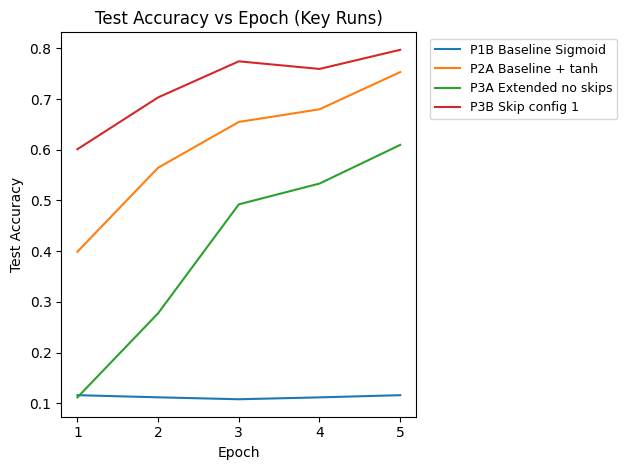

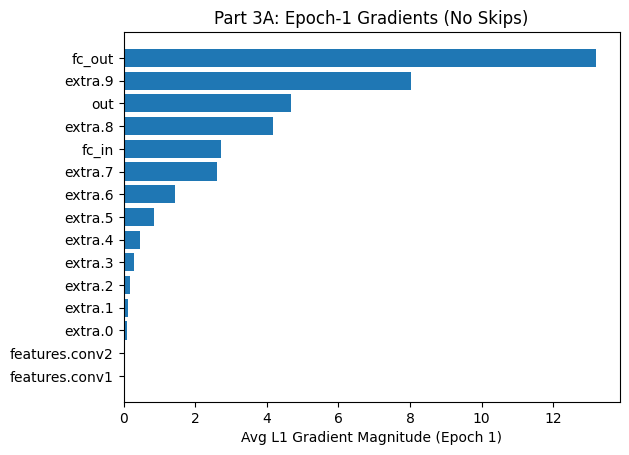

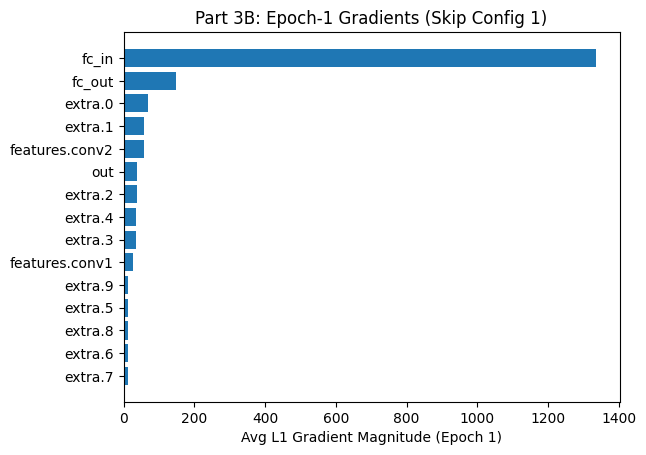

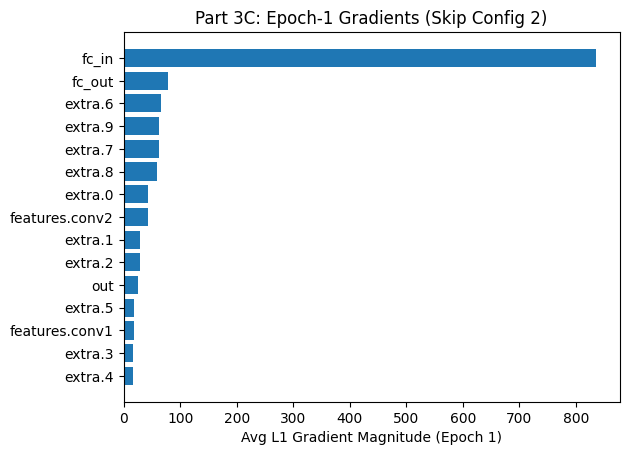


DONE ✅
Next step: paste the printed RESULTS SUMMARY TABLE + any key observations you noticed.



In [ ]:
"""
===========================================================
LAB 2 (CSCI 5922) — EUROSAT LAND-COVER CLASSIFICATION (FINAL)
===========================================================

This version is designed to leave NO loopholes with clarified lab rules.

Key compliance points:
1) NO torch.optim
2) Only allowed modules in model definitions:
   - nn.Conv2d, nn.MaxPool2d, nn.Linear
3) Activations are implemented from scratch using tensor ops
4) Softmax + cross-entropy are from scratch
5) ONE fixed 70/30 split used for ALL experiments
6) Manual gradient reset + manual update step
7) IMPORTANT CLARIFICATION COMPLIANCE:
   - We do NOT use model.parameters() or model.named_parameters()
   - We access parameters ONLY via module.weight / module.bias

We also include:
- Macro Precision + Macro Recall (required)
- Part 3 gradient L1 reporting (per-layer + overall avg)
- Optional plots (learning curves + gradient plots)

HOW TO USE:
- Run this script end-to-end
- Copy the printed “RESULTS SUMMARY TABLE” and send it to me
- Then we write Methods/Results/Analysis section-by-section
"""

import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Optional

import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


# ===========================================================
# 0) Pretty printing helpers (for report-ready output)
# ===========================================================
def banner(title: str) -> None:
    print("\n" + "=" * 78)
    print(title)
    print("=" * 78)

def subbanner(title: str) -> None:
    print("\n" + "-" * 78)
    print(title)
    print("-" * 78)

def fmt_pct(x: float) -> str:
    return f"{100.0 * x:6.2f}%"

def fmt_float(x: float) -> str:
    return f"{x:.6f}"

def print_kv(items: List[Tuple[str, str]]) -> None:
    maxk = max(len(k) for k, _ in items) if items else 0
    for k, v in items:
        print(f"{k:<{maxk}} : {v}")

def random_chance_accuracy(num_classes: int) -> float:
    return 1.0 / max(1, num_classes)

def difficulty_pass_fail(acc: float, threshold: float = 0.50) -> str:
    return "PASS ✅ (dataset is difficult enough)" if acc <= threshold else "FAIL ⚠️ (too easy)"


# ===========================================================
# 1) Reproducibility (so results are consistent)
# ===========================================================
def set_seed(seed: int = 42) -> None:
    """
    Why we do this:
    - Train/test split uses randomness.
    - Weight initialization uses randomness.
    - Without a fixed seed, two runs might differ and comparisons become unfair.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)


# ===========================================================
# 2) Manual activation functions (forward pass from scratch)
# ===========================================================
def act_sigmoid(x: torch.Tensor) -> torch.Tensor:
    """Sigmoid: σ(x)=1/(1+e^{-x}). Can cause vanishing gradients in deep nets."""
    return 1.0 / (1.0 + torch.exp(-x))

def act_tanh(x: torch.Tensor) -> torch.Tensor:
    """tanh(x) = (e^x - e^{-x}) / (e^x + e^{-x}). Zero-centered; often more stable."""
    ex = torch.exp(x)
    enx = torch.exp(-x)
    return (ex - enx) / (ex + enx)

def act_leaky_relu(x: torch.Tensor, slope: float = 0.1) -> torch.Tensor:
    """LeakyReLU: f(x)=x if x>=0 else slope*x. Keeps gradient for negative inputs."""
    return torch.maximum(x, slope * x)

def act_leaky_relu_01(x: torch.Tensor) -> torch.Tensor:
    """Helper wrapper so we don't use lambdas in experiments."""
    return act_leaky_relu(x, slope=0.1)


# ===========================================================
# 3) Softmax + Cross-Entropy from scratch
# ===========================================================
def softmax(logits: torch.Tensor, dim: int = 1) -> torch.Tensor:
    """
    Stable softmax:
      softmax(z)_i = exp(z_i - max(z)) / sum_j exp(z_j - max(z))
    """
    maxv = torch.max(logits, dim=dim, keepdim=True).values
    ex = torch.exp(logits - maxv)
    return ex / torch.sum(ex, dim=dim, keepdim=True)

def cross_entropy_from_probs(probs: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Multi-class NLL from softmax probabilities:
      L = mean_i [-log(p_i[y_i])]
    """
    eps = 1e-12
    picked = probs[torch.arange(probs.size(0)), y]
    return -torch.mean(torch.log(picked + eps))


# ===========================================================
# 4) Metrics: Accuracy, Macro Precision, Macro Recall (required)
# ===========================================================
@torch.no_grad()
def compute_metrics(y_true: torch.Tensor, y_pred: torch.Tensor, num_classes: int) -> Dict[str, float]:
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for t, p in zip(y_true, y_pred):
        cm[t.long(), p.long()] += 1

    total = cm.sum().item()
    correct = torch.trace(cm).item()
    acc = correct / total if total > 0 else 0.0

    precisions, recalls = [], []
    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)

    return {
        "accuracy": acc,
        "macro_precision": sum(precisions) / max(1, num_classes),
        "macro_recall": sum(recalls) / max(1, num_classes),
    }

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int,
    activation: Callable[[torch.Tensor], torch.Tensor],
    skip_config: Optional[List[Tuple[int, int]]] = None
) -> Dict[str, float]:
    model.eval()
    y_true_all, y_pred_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        probs = forward_probs(model, xb, activation, skip_config)
        pred = torch.argmax(probs, dim=1)
        y_true_all.append(yb.detach().cpu())
        y_pred_all.append(pred.detach().cpu())

    y_true = torch.cat(y_true_all, dim=0)
    y_pred = torch.cat(y_pred_all, dim=0)
    return compute_metrics(y_true, y_pred, num_classes)


# ===========================================================
# 5) Dataset: EuroSAT + ONE fixed split for all experiments
# ===========================================================
def build_eurosat_dataset(root="./data", image_size=64):
    """
    Preprocessing:
    - Resize to fixed (image_size, image_size)
    - ToTensor maps to [0,1]
    - Normalize with mean=0.5/std=0.5 -> approximately [-1,1]
    """
    tfm = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ])
    ds = datasets.EuroSAT(root=root, download=True, transform=tfm)
    return ds

def fixed_split(ds, train_ratio=0.7, seed=42):
    n_total = len(ds)
    n_train = int(train_ratio * n_total)
    n_test = n_total - n_train
    gen = torch.Generator().manual_seed(seed)
    train_ds, test_ds = random_split(ds, [n_train, n_test], generator=gen)
    return train_ds, test_ds

def make_loader(subset, batch_size, shuffle, num_workers=2):
    return DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True
    )

def dataset_quick_stats(train_ds, test_ds, num_classes: int) -> Dict[str, Dict[int, int]]:
    """
    Small helper to show class distribution in train/test.
    NOTE: We only use dataset indexing here; no training logic depends on it.
    """
    train_counts = {i: 0 for i in range(num_classes)}
    test_counts = {i: 0 for i in range(num_classes)}

    # random_split returns Subset objects with .indices into original dataset
    for idx in train_ds.indices:
        _, y = train_ds.dataset[idx]
        train_counts[int(y)] += 1

    for idx in test_ds.indices:
        _, y = test_ds.dataset[idx]
        test_counts[int(y)] += 1

    return {"train": train_counts, "test": test_counts}

def print_class_counts(ds_classes: List[str], counts: Dict[int, int], title: str) -> None:
    subbanner(title)
    total = sum(counts.values())
    print(f"Total samples in this split: {total}")
    for i, name in enumerate(ds_classes):
        c = counts.get(i, 0)
        frac = (c / total) if total > 0 else 0.0
        print(f"  {i:2d} | {name:<18s} : {c:5d}  ({fmt_pct(frac)})")


# ===========================================================
# 6) Models: only allowed modules + manual activations
# ===========================================================
class SimpleCNNFeature(nn.Module):
    """
    conv -> activation -> pool -> conv -> activation -> pool
    """
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

    def forward(self, x: torch.Tensor, activation: Callable[[torch.Tensor], torch.Tensor]) -> torch.Tensor:
        x = self.pool1(activation(self.conv1(x)))
        x = self.pool2(activation(self.conv2(x)))
        return x

class ShallowTwoLayerNet(nn.Module):
    """
    Part 1A difficulty check:
      Flatten -> Linear -> sigmoid -> Linear -> softmax
    """
    def __init__(self, in_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        h = act_sigmoid(self.fc1(x))
        logits = self.fc2(h)
        return softmax(logits, dim=1)

class BaselineDeepNet(nn.Module):
    """
    Part 1B baseline deep model (>=5 parameterized layers).
    """
    def __init__(self, image_size: int, num_classes: int, hidden_dim: int = 256):
        super().__init__()
        self.features = SimpleCNNFeature(3)

        feat_h = image_size // 4
        feat_w = image_size // 4
        feat_dim = 32 * feat_h * feat_w

        self.fc1 = nn.Linear(feat_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x: torch.Tensor, activation: Callable[[torch.Tensor], torch.Tensor]) -> torch.Tensor:
        z = self.features(x, activation)
        z = z.view(z.size(0), -1)

        z = activation(self.fc1(z))
        z = activation(self.fc2(z))
        z = activation(self.fc3(z))
        z = activation(self.fc4(z))
        z = activation(self.fc5(z))

        logits = self.out(z)
        return softmax(logits, dim=1)

class ExtendedDeepNetWithSkips(nn.Module):
    """
    Part 3: Extended model (+10 layers) + optional skip connections.
    """
    def __init__(self, image_size: int, num_classes: int, hidden_dim: int = 256, extra_layers: int = 10):
        super().__init__()
        self.features = SimpleCNNFeature(3)

        feat_h = image_size // 4
        feat_w = image_size // 4
        feat_dim = 32 * feat_h * feat_w

        self.fc_in = nn.Linear(feat_dim, hidden_dim)
        self.extra = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(extra_layers)])
        self.fc_out = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)

    def forward(
        self,
        x: torch.Tensor,
        activation: Callable[[torch.Tensor], torch.Tensor],
        skip_config: Optional[List[Tuple[int, int]]] = None
    ) -> torch.Tensor:
        z = self.features(x, activation)
        z = z.view(z.size(0), -1)

        states: List[torch.Tensor] = []
        z = activation(self.fc_in(z))
        states.append(z)  # state 0

        skip_to: Dict[int, List[int]] = {}
        if skip_config:
            for frm, to in skip_config:
                skip_to.setdefault(to, []).append(frm)

        for i, layer in enumerate(self.extra, start=1):
            z = activation(layer(z))
            if i in skip_to:
                for frm in skip_to[i]:
                    z = z + states[frm]  # real in-stream residual
            states.append(z)

        z = activation(self.fc_out(z))
        logits = self.out(z)
        return softmax(logits, dim=1)


# ===========================================================
# 7) STRICT RULE COMPLIANCE:
#    NO model.parameters() and NO model.named_parameters()
#    Collect params ONLY via module.weight / module.bias
# ===========================================================
def _add_param(named: List[Tuple[str, torch.Tensor]], name: str, t: Optional[torch.Tensor]) -> None:
    if t is not None:
        named.append((name, t))

def get_named_params(model: nn.Module) -> List[Tuple[str, torch.Tensor]]:
    named: List[Tuple[str, torch.Tensor]] = []

    if isinstance(model, ShallowTwoLayerNet):
        _add_param(named, "fc1.weight", model.fc1.weight)
        _add_param(named, "fc1.bias",   model.fc1.bias)
        _add_param(named, "fc2.weight", model.fc2.weight)
        _add_param(named, "fc2.bias",   model.fc2.bias)
        return named

    if isinstance(model, BaselineDeepNet):
        _add_param(named, "features.conv1.weight", model.features.conv1.weight)
        _add_param(named, "features.conv1.bias",   model.features.conv1.bias)
        _add_param(named, "features.conv2.weight", model.features.conv2.weight)
        _add_param(named, "features.conv2.bias",   model.features.conv2.bias)

        for i in range(1, 6):
            fc = getattr(model, f"fc{i}")
            _add_param(named, f"fc{i}.weight", fc.weight)
            _add_param(named, f"fc{i}.bias",   fc.bias)

        _add_param(named, "out.weight", model.out.weight)
        _add_param(named, "out.bias",   model.out.bias)
        return named

    if isinstance(model, ExtendedDeepNetWithSkips):
        _add_param(named, "features.conv1.weight", model.features.conv1.weight)
        _add_param(named, "features.conv1.bias",   model.features.conv1.bias)
        _add_param(named, "features.conv2.weight", model.features.conv2.weight)
        _add_param(named, "features.conv2.bias",   model.features.conv2.bias)

        _add_param(named, "fc_in.weight", model.fc_in.weight)
        _add_param(named, "fc_in.bias",   model.fc_in.bias)

        for i, layer in enumerate(model.extra):
            _add_param(named, f"extra.{i}.weight", layer.weight)
            _add_param(named, f"extra.{i}.bias",   layer.bias)

        _add_param(named, "fc_out.weight", model.fc_out.weight)
        _add_param(named, "fc_out.bias",   model.fc_out.bias)

        _add_param(named, "out.weight", model.out.weight)
        _add_param(named, "out.bias",   model.out.bias)
        return named

    raise ValueError("Unknown model type")

def zero_grads_named(named_params: List[Tuple[str, torch.Tensor]]) -> None:
    for _, p in named_params:
        p.grad = None


# ===========================================================
# 8) Manual optimizers: SGD / Momentum / Weight Decay
# ===========================================================
@dataclass
class OptimConfig:
    lr: float = 1e-3
    momentum_alpha: float = 0.0
    weight_decay_beta: float = 0.0
    batch_size: int = 1

class MomentumState:
    def __init__(self):
        self.vel: Dict[int, torch.Tensor] = {}

def apply_update(named_params: List[Tuple[str, torch.Tensor]], cfg: OptimConfig, mom: MomentumState) -> None:
    for _, p in named_params:
        if p.grad is None:
            continue
        g = p.grad.data

        if cfg.momentum_alpha > 0.0 or cfg.weight_decay_beta > 0.0:
            key = id(p)
            if key not in mom.vel:
                mom.vel[key] = torch.zeros_like(p.data)

            v = mom.vel[key]
            if cfg.weight_decay_beta != 0.0:
                v_next = cfg.momentum_alpha * v + g + cfg.weight_decay_beta * p.data
            else:
                v_next = cfg.momentum_alpha * v + g

            mom.vel[key] = v_next
            p.data = p.data - cfg.lr * v_next
        else:
            p.data = p.data - cfg.lr * g


# ===========================================================
# 9) Part 3 Gradient reporting: per-layer L1 + overall avg
# ===========================================================
def layer_key_from_param_name(param_name: str) -> str:
    if param_name.endswith(".weight"):
        return param_name[:-len(".weight")]
    if param_name.endswith(".bias"):
        return param_name[:-len(".bias")]
    return param_name

def summarize_epoch1_gradients_layerwise(grad_l1_param_avg: Dict[str, float]) -> Dict[str, object]:
    buckets: Dict[str, List[float]] = {}
    for pname, val in grad_l1_param_avg.items():
        lk = layer_key_from_param_name(pname)
        buckets.setdefault(lk, []).append(val)

    layer_avg = {lk: sum(vals) / len(vals) for lk, vals in buckets.items()}
    overall_layer_avg = sum(layer_avg.values()) / max(1, len(layer_avg))
    return {"layer_avg": layer_avg, "overall_layer_avg": overall_layer_avg}

def print_layerwise_grad_report(title: str, grad_summary: Dict[str, object], top_k: int = 15) -> None:
    subbanner(title)
    layer_avg: Dict[str, float] = grad_summary["layer_avg"]
    overall = grad_summary["overall_layer_avg"]

    items = sorted(layer_avg.items(), key=lambda kv: kv[1], reverse=True)

    print(f"Overall avg across layers (epoch 1): {fmt_float(overall)}")
    print(f"Top {top_k} layers by avg L1 grad size (epoch 1):")
    for lk, v in items[:top_k]:
        print(f"  {lk:<28s} : {fmt_float(v)}")


# ===========================================================
# 10) Forward dispatcher
# ===========================================================
def forward_probs(
    model: nn.Module,
    xb: torch.Tensor,
    activation: Callable[[torch.Tensor], torch.Tensor],
    skip_config: Optional[List[Tuple[int, int]]] = None
) -> torch.Tensor:
    if isinstance(model, ShallowTwoLayerNet):
        return model(xb)
    if isinstance(model, BaselineDeepNet):
        return model(xb, activation)
    if isinstance(model, ExtendedDeepNetWithSkips):
        return model(xb, activation, skip_config)
    raise ValueError("Unknown model class")


# ===========================================================
# 11) Training loop (mini-batch SGD via mean loss)
# ===========================================================
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    activation: Callable[[torch.Tensor], torch.Tensor],
    cfg: OptimConfig,
    mom_state: MomentumState,
    record_grad_epoch1: bool = False,
    skip_config: Optional[List[Tuple[int, int]]] = None
) -> Tuple[float, Optional[Dict[str, float]]]:

    model.train()
    named_params = get_named_params(model)

    total_loss = 0.0
    num_updates = 0
    grad_l1_sum = {} if record_grad_epoch1 else None

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        # (1) reset gradients
        zero_grads_named(named_params)

        # (2) forward
        probs = forward_probs(model, xb, activation, skip_config)

        # (3) mean loss over batch
        loss = cross_entropy_from_probs(probs, yb)

        # (4) backward -> grads of mean loss = mean gradient across batch samples
        loss.backward()

        # (5) record epoch-1 gradients if required
        if record_grad_epoch1:
            for pname, p in named_params:
                if p.grad is not None:
                    grad_l1_sum[pname] = grad_l1_sum.get(pname, 0.0) + torch.sum(torch.abs(p.grad)).item()

        # (6) update
        apply_update(named_params, cfg, mom_state)

        total_loss += loss.item()
        num_updates += 1

    avg_loss = total_loss / max(1, num_updates)

    if record_grad_epoch1 and grad_l1_sum is not None:
        grad_l1_avg = {k: v / max(1, num_updates) for k, v in grad_l1_sum.items()}
        return avg_loss, grad_l1_avg

    return avg_loss, None


def run_experiment(
    deliverable_tag: str,
    title: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    num_classes: int,
    activation: Callable[[torch.Tensor], torch.Tensor],
    cfg: OptimConfig,
    epochs: int,
    record_grad_epoch1: bool = False,
    skip_config: Optional[List[Tuple[int, int]]] = None,
    history: Optional[Dict[str, List[float]]] = None
) -> Dict[str, object]:

    banner(f"{deliverable_tag} — {title}")

    # Print configuration in a human way
    print_kv([
        ("Device", DEVICE),
        ("Epochs", str(epochs)),
        ("Batch size", str(cfg.batch_size)),
        ("Learning rate", str(cfg.lr)),
        ("Momentum alpha", str(cfg.momentum_alpha)),
        ("Weight decay beta", str(cfg.weight_decay_beta)),
    ])

    model = model.to(DEVICE)
    mom_state = MomentumState()

    epoch1_grad_param_avg = None
    last_metrics = None

    for ep in range(1, epochs + 1):
        record_now = (record_grad_epoch1 and ep == 1)

        train_loss, grad_param_avg = train_one_epoch(
            model=model,
            loader=train_loader,
            activation=activation,
            cfg=cfg,
            mom_state=mom_state,
            record_grad_epoch1=record_now,
            skip_config=skip_config
        )

        metrics = evaluate(model, test_loader, num_classes, activation, skip_config)
        last_metrics = metrics

        if record_now:
            epoch1_grad_param_avg = grad_param_avg

        if history is not None:
            history["train_loss"].append(train_loss)
            history["test_acc"].append(metrics["accuracy"])

        print(
            f"Epoch {ep:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"test_acc={fmt_pct(metrics['accuracy'])} | "
            f"macroP={fmt_pct(metrics['macro_precision'])} | "
            f"macroR={fmt_pct(metrics['macro_recall'])}"
        )

    grad_layer_report = None
    if record_grad_epoch1 and epoch1_grad_param_avg is not None:
        grad_layer_report = summarize_epoch1_gradients_layerwise(epoch1_grad_param_avg)

    # Friendly final summary line (report-ready)
    subbanner("Final TEST Metrics (use this in Results)")
    print_kv([
        ("Accuracy", fmt_pct(last_metrics["accuracy"])),
        ("Macro Precision", fmt_pct(last_metrics["macro_precision"])),
        ("Macro Recall", fmt_pct(last_metrics["macro_recall"])),
    ])

    return {
        "deliverable": deliverable_tag,
        "title": title,
        "final_metrics": last_metrics,
        "epoch1_grad_param_avg": epoch1_grad_param_avg,
        "epoch1_grad_layer_report": grad_layer_report,
        "model": model,
        "cfg": cfg,
    }


# ===========================================================
# 12) Results table (for your report)
# ===========================================================
def add_result_row(
    results: List[Dict[str, object]],
    deliverable: str,
    experiment: str,
    activation_name: str,
    batch_size: int,
    lr: float,
    momentum_alpha: float,
    weight_decay_beta: float,
    metrics: Dict[str, float]
) -> None:
    results.append({
        "Deliverable": deliverable,
        "Experiment": experiment,
        "Activation": activation_name,
        "Batch": batch_size,
        "LR": lr,
        "Alpha": momentum_alpha,
        "Beta": weight_decay_beta,
        "Acc": metrics["accuracy"],
        "MacroP": metrics["macro_precision"],
        "MacroR": metrics["macro_recall"],
    })

def print_results_summary_table(results: List[Dict[str, object]]) -> None:
    banner("RESULTS SUMMARY TABLE (copy into your report)")

    headers = ["Deliverable", "Experiment", "Activation", "Batch", "LR", "Alpha", "Beta", "Acc", "MacroP", "MacroR"]
    rows = []
    for r in results:
        rows.append([
            r["Deliverable"],
            r["Experiment"],
            r["Activation"],
            str(r["Batch"]),
            f"{r['LR']:.1e}",
            f"{r['Alpha']:.2f}",
            f"{r['Beta']:.1e}" if r["Beta"] != 0 else "0",
            fmt_pct(r["Acc"]),
            fmt_pct(r["MacroP"]),
            fmt_pct(r["MacroR"]),
        ])

    # Compute column widths
    widths = [len(h) for h in headers]
    for row in rows:
        for j, cell in enumerate(row):
            widths[j] = max(widths[j], len(cell))

    # Print table
    header_line = " | ".join(headers[j].ljust(widths[j]) for j in range(len(headers)))
    sep_line = "-+-".join("-" * widths[j] for j in range(len(headers)))
    print(header_line)
    print(sep_line)
    for row in rows:
        print(" | ".join(row[j].ljust(widths[j]) for j in range(len(headers))))


# ===========================================================
# 13) Plot helpers (optional)
# ===========================================================
def plot_learning_curves(histories: Dict[str, Dict[str, List[float]]]) -> None:
    plt.figure()
    for name, h in histories.items():
        plt.plot(range(1, len(h["test_acc"]) + 1), h["test_acc"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Test Accuracy")
    plt.title("Test Accuracy vs Epoch (Key Runs)")
    plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_top_gradients(title: str, grad_layer_report: Dict[str, object], top_k: int = 15) -> None:
    layer_avg: Dict[str, float] = grad_layer_report["layer_avg"]
    items = sorted(layer_avg.items(), key=lambda kv: kv[1], reverse=True)[:top_k]

    labels = [k for k, _ in items][::-1]
    vals = [v for _, v in items][::-1]

    plt.figure()
    plt.barh(labels, vals)
    plt.xlabel("Avg L1 Gradient Magnitude (Epoch 1)")
    plt.title(title)
    plt.show()


# ===========================================================
# 14) MAIN: Parts 1–3 with deliverable-based printing
# ===========================================================
def main():
    banner("LAB 2 START — EUROSTAT LAND COVER CLASSIFICATION")
    print_kv([("Device detected", DEVICE), ("Seed", "42")])

    IMAGE_SIZE = 64
    EPOCHS_P1A = 3
    EPOCHS_P1B = 5
    EPOCHS_P2  = 5
    EPOCHS_P3  = 5

    # ---------------------------
    # DELIVERABLE: Dataset + Preprocessing + Split
    # ---------------------------
    banner("DELIVERABLE (Part 1): Dataset Selection + Preprocessing + Fixed Split")

    ds = build_eurosat_dataset(root="./data", image_size=IMAGE_SIZE)
    num_classes = len(ds.classes)

    print_kv([
        ("Dataset", "torchvision.datasets.EuroSAT"),
        ("Classes", str(num_classes)),
        ("Total samples", str(len(ds))),
        ("Image size", f"{IMAGE_SIZE}x{IMAGE_SIZE}"),
        ("Transforms", "Resize -> ToTensor -> Normalize(mean=0.5,std=0.5)"),
        ("Split", "70% train / 30% test (fixed seed split)"),
    ])

    train_ds, test_ds = fixed_split(ds, train_ratio=0.7, seed=42)
    print_kv([
        ("Train size", str(len(train_ds))),
        ("Test size", str(len(test_ds))),
    ])

    # Optional: class distribution print (helps Methods justification)
    counts = dataset_quick_stats(train_ds, test_ds, num_classes)
    print_class_counts(ds.classes, counts["train"], "Train class distribution")
    print_class_counts(ds.classes, counts["test"], "Test class distribution")

    def loaders_for_b(b: int):
        return (
            make_loader(train_ds, batch_size=b, shuffle=True, num_workers=2),
            make_loader(test_ds, batch_size=b, shuffle=False, num_workers=2),
        )

    # Store results + histories for plots
    results: List[Dict[str, object]] = []
    histories: Dict[str, Dict[str, List[float]]] = {}

    # =======================================================
    # PART 1A — Difficulty Check (Shallow 2-layer Sigmoid)
    # =======================================================
    train_b1, test_b1 = loaders_for_b(1)

    shallow_in_dim = 3 * IMAGE_SIZE * IMAGE_SIZE
    shallow = ShallowTwoLayerNet(in_dim=shallow_in_dim, hidden_dim=64, num_classes=num_classes)
    cfg_shallow = OptimConfig(lr=1e-3, batch_size=1)

    histories["P1A_Shallow"] = {"train_loss": [], "test_acc": []}
    res_1a = run_experiment(
        deliverable_tag="Part 1A (Difficulty Check)",
        title="Shallow 2-layer MLP (Sigmoid) with SGD, batch=1",
        model=shallow,
        train_loader=train_b1,
        test_loader=test_b1,
        num_classes=num_classes,
        activation=act_sigmoid,
        cfg=cfg_shallow,
        epochs=EPOCHS_P1A,
        history=histories["P1A_Shallow"]
    )

    add_result_row(
        results,
        deliverable="1A",
        experiment="Shallow MLP",
        activation_name="sigmoid",
        batch_size=1,
        lr=cfg_shallow.lr,
        momentum_alpha=cfg_shallow.momentum_alpha,
        weight_decay_beta=cfg_shallow.weight_decay_beta,
        metrics=res_1a["final_metrics"]
    )

    # Print the “difficulty check” conclusion (report-ready)
    subbanner("Difficulty Check Conclusion")
    acc1a = res_1a["final_metrics"]["accuracy"]
    print_kv([
        ("Shallow model accuracy", fmt_pct(acc1a)),
        ("Threshold", "50.00%"),
        ("Result", difficulty_pass_fail(acc1a, 0.50)),
    ])

    # =======================================================
    # PART 1B — Baseline Deep Network (Sigmoid, SGD, batch=1)
    # =======================================================
    baseline = BaselineDeepNet(image_size=IMAGE_SIZE, num_classes=num_classes, hidden_dim=256)
    cfg_base = OptimConfig(lr=1e-3, batch_size=1)

    histories["P1B_BaselineSigmoid"] = {"train_loss": [], "test_acc": []}
    res_1b = run_experiment(
        deliverable_tag="Part 1B (Baseline Deep Model)",
        title="Baseline Deep Net (Sigmoid) with SGD, batch=1",
        model=baseline,
        train_loader=train_b1,
        test_loader=test_b1,
        num_classes=num_classes,
        activation=act_sigmoid,
        cfg=cfg_base,
        epochs=EPOCHS_P1B,
        history=histories["P1B_BaselineSigmoid"]
    )

    add_result_row(
        results,
        deliverable="1B",
        experiment="Baseline Deep Net",
        activation_name="sigmoid",
        batch_size=1,
        lr=cfg_base.lr,
        momentum_alpha=cfg_base.momentum_alpha,
        weight_decay_beta=cfg_base.weight_decay_beta,
        metrics=res_1b["final_metrics"]
    )

    # Random chance note (helpful for analysis)
    subbanner("Baseline vs Random Chance (context for analysis)")
    rc = random_chance_accuracy(num_classes)
    print_kv([
        ("#Classes", str(num_classes)),
        ("Random chance accuracy", fmt_pct(rc)),
        ("Baseline accuracy", fmt_pct(res_1b["final_metrics"]["accuracy"])),
    ])

    # =======================================================
    # PART 2A / 2B — Two Activation Experiments (one per run)
    # =======================================================
    # 2A: tanh
    baseline_tanh = BaselineDeepNet(IMAGE_SIZE, num_classes, hidden_dim=256)
    histories["P2A_Tanh_B1"] = {"train_loss": [], "test_acc": []}
    res_2a = run_experiment(
        deliverable_tag="Part 2A (Activation Experiment 1)",
        title="Baseline + tanh with SGD, batch=1",
        model=baseline_tanh,
        train_loader=train_b1,
        test_loader=test_b1,
        num_classes=num_classes,
        activation=act_tanh,
        cfg=cfg_base,
        epochs=EPOCHS_P2,
        history=histories["P2A_Tanh_B1"]
    )

    add_result_row(
        results,
        deliverable="2A",
        experiment="Baseline + tanh",
        activation_name="tanh",
        batch_size=1,
        lr=cfg_base.lr,
        momentum_alpha=cfg_base.momentum_alpha,
        weight_decay_beta=cfg_base.weight_decay_beta,
        metrics=res_2a["final_metrics"]
    )

    # 2B: leaky relu
    baseline_lrelu = BaselineDeepNet(IMAGE_SIZE, num_classes, hidden_dim=256)
    histories["P2B_LeakyReLU_B1"] = {"train_loss": [], "test_acc": []}
    res_2b = run_experiment(
        deliverable_tag="Part 2B (Activation Experiment 2)",
        title="Baseline + LeakyReLU with SGD, batch=1",
        model=baseline_lrelu,
        train_loader=train_b1,
        test_loader=test_b1,
        num_classes=num_classes,
        activation=act_leaky_relu_01,
        cfg=cfg_base,
        epochs=EPOCHS_P2,
        history=histories["P2B_LeakyReLU_B1"]
    )

    add_result_row(
        results,
        deliverable="2B",
        experiment="Baseline + LeakyReLU",
        activation_name="leaky_relu(0.1)",
        batch_size=1,
        lr=cfg_base.lr,
        momentum_alpha=cfg_base.momentum_alpha,
        weight_decay_beta=cfg_base.weight_decay_beta,
        metrics=res_2b["final_metrics"]
    )

    # Choose best activation based on final accuracy
    best_act_name, best_act = ("tanh", act_tanh) if res_2a["final_metrics"]["accuracy"] >= res_2b["final_metrics"]["accuracy"] else ("leaky_relu(0.1)", act_leaky_relu_01)
    subbanner("Activation Winner (used for next deliverables)")
    print_kv([
        ("Winner", best_act_name),
        ("Reason", "Highest final test accuracy among the two activation experiments"),
    ])

    # =======================================================
    # PART 2C — Mini-batch SGD with best activation (try b)
    # =======================================================
    batch_sizes = [8, 32, 64]
    mb_runs = []

    for b in batch_sizes:
        train_b, test_b = loaders_for_b(b)
        m = BaselineDeepNet(IMAGE_SIZE, num_classes, hidden_dim=256)
        cfg_mb = OptimConfig(lr=1e-3, batch_size=b)

        res_mb = run_experiment(
            deliverable_tag="Part 2C (Mini-batch SGD)",
            title=f"Mini-batch SGD (b={b}) using best activation ({best_act_name})",
            model=m,
            train_loader=train_b,
            test_loader=test_b,
            num_classes=num_classes,
            activation=best_act,
            cfg=cfg_mb,
            epochs=EPOCHS_P2
        )
        mb_runs.append((b, res_mb))

        add_result_row(
            results,
            deliverable="2C",
            experiment=f"Mini-batch SGD b={b}",
            activation_name=best_act_name,
            batch_size=b,
            lr=cfg_mb.lr,
            momentum_alpha=cfg_mb.momentum_alpha,
            weight_decay_beta=cfg_mb.weight_decay_beta,
            metrics=res_mb["final_metrics"]
        )

    mb_runs.sort(key=lambda x: x[1]["final_metrics"]["accuracy"], reverse=True)
    best_b = mb_runs[0][0]
    subbanner("Best Batch Size (used for momentum + Part 3)")
    print_kv([("Best batch size", str(best_b))])

    # =======================================================
    # PART 2D — Mini-batch SGD + Momentum (try alphas)
    # =======================================================
    train_bestb, test_bestb = loaders_for_b(best_b)
    alphas = [0.5, 0.9, 0.95]
    mom_runs = []

    for a in alphas:
        m = BaselineDeepNet(IMAGE_SIZE, num_classes, hidden_dim=256)
        cfg_mom = OptimConfig(lr=1e-3, batch_size=best_b, momentum_alpha=a)

        res_mom = run_experiment(
            deliverable_tag="Part 2D (Momentum)",
            title=f"Mini-batch SGD + Momentum (alpha={a}) using best activation ({best_act_name})",
            model=m,
            train_loader=train_bestb,
            test_loader=test_bestb,
            num_classes=num_classes,
            activation=best_act,
            cfg=cfg_mom,
            epochs=EPOCHS_P2
        )
        mom_runs.append((a, res_mom))

        add_result_row(
            results,
            deliverable="2D",
            experiment=f"Momentum alpha={a}",
            activation_name=best_act_name,
            batch_size=best_b,
            lr=cfg_mom.lr,
            momentum_alpha=cfg_mom.momentum_alpha,
            weight_decay_beta=cfg_mom.weight_decay_beta,
            metrics=res_mom["final_metrics"]
        )

    mom_runs.sort(key=lambda x: x[1]["final_metrics"]["accuracy"], reverse=True)
    best_alpha = mom_runs[0][0]
    subbanner("Best Momentum Alpha (used for Part 3)")
    print_kv([("Best alpha", str(best_alpha))])

    # =======================================================
    # PART 3A — Extended +10 layers, record epoch-1 gradients
    # =======================================================
    ext = ExtendedDeepNetWithSkips(IMAGE_SIZE, num_classes, hidden_dim=256, extra_layers=10)
    cfg_ext = OptimConfig(lr=1e-3, batch_size=best_b, momentum_alpha=best_alpha)

    histories["P3A_Extended_NoSkips"] = {"train_loss": [], "test_acc": []}
    res_3a = run_experiment(
        deliverable_tag="Part 3A (Extended Model)",
        title="Extended model (+10 layers), no skips — record epoch-1 gradients",
        model=ext,
        train_loader=train_bestb,
        test_loader=test_bestb,
        num_classes=num_classes,
        activation=best_act,
        cfg=cfg_ext,
        epochs=EPOCHS_P3,
        record_grad_epoch1=True,
        skip_config=None,
        history=histories["P3A_Extended_NoSkips"]
    )

    add_result_row(
        results,
        deliverable="3A",
        experiment="Extended (+10), no skips",
        activation_name=best_act_name,
        batch_size=best_b,
        lr=cfg_ext.lr,
        momentum_alpha=cfg_ext.momentum_alpha,
        weight_decay_beta=cfg_ext.weight_decay_beta,
        metrics=res_3a["final_metrics"]
    )

    if res_3a["epoch1_grad_layer_report"] is not None:
        print_layerwise_grad_report("Part 3A Gradient Report (epoch 1)", res_3a["epoch1_grad_layer_report"])

    # =======================================================
    # PART 3B / 3C — Two skip configs (3 skips each)
    # =======================================================
    skip_config_1 = [(0, 2), (2, 5), (5, 10)]
    skip_config_2 = [(0, 1), (1, 3), (3, 6)]

    s1 = ExtendedDeepNetWithSkips(IMAGE_SIZE, num_classes, hidden_dim=256, extra_layers=10)
    histories["P3B_Skip1"] = {"train_loss": [], "test_acc": []}
    res_3b = run_experiment(
        deliverable_tag="Part 3B (Skip Config 1)",
        title=f"Skip config 1: {skip_config_1} — record epoch-1 gradients",
        model=s1,
        train_loader=train_bestb,
        test_loader=test_bestb,
        num_classes=num_classes,
        activation=best_act,
        cfg=cfg_ext,
        epochs=EPOCHS_P3,
        record_grad_epoch1=True,
        skip_config=skip_config_1,
        history=histories["P3B_Skip1"]
    )

    add_result_row(
        results,
        deliverable="3B",
        experiment="Skip config 1",
        activation_name=best_act_name,
        batch_size=best_b,
        lr=cfg_ext.lr,
        momentum_alpha=cfg_ext.momentum_alpha,
        weight_decay_beta=cfg_ext.weight_decay_beta,
        metrics=res_3b["final_metrics"]
    )

    if res_3b["epoch1_grad_layer_report"] is not None:
        print_layerwise_grad_report("Part 3B Gradient Report (epoch 1)", res_3b["epoch1_grad_layer_report"])

    s2 = ExtendedDeepNetWithSkips(IMAGE_SIZE, num_classes, hidden_dim=256, extra_layers=10)
    histories["P3C_Skip2"] = {"train_loss": [], "test_acc": []}
    res_3c = run_experiment(
        deliverable_tag="Part 3C (Skip Config 2)",
        title=f"Skip config 2: {skip_config_2} — record epoch-1 gradients",
        model=s2,
        train_loader=train_bestb,
        test_loader=test_bestb,
        num_classes=num_classes,
        activation=best_act,
        cfg=cfg_ext,
        epochs=EPOCHS_P3,
        record_grad_epoch1=True,
        skip_config=skip_config_2,
        history=histories["P3C_Skip2"]
    )

    add_result_row(
        results,
        deliverable="3C",
        experiment="Skip config 2",
        activation_name=best_act_name,
        batch_size=best_b,
        lr=cfg_ext.lr,
        momentum_alpha=cfg_ext.momentum_alpha,
        weight_decay_beta=cfg_ext.weight_decay_beta,
        metrics=res_3c["final_metrics"]
    )

    if res_3c["epoch1_grad_layer_report"] is not None:
        print_layerwise_grad_report("Part 3C Gradient Report (epoch 1)", res_3c["epoch1_grad_layer_report"])

    # =======================================================
    # FINAL: print summary table (this is what you’ll paste to me)
    # =======================================================
    print_results_summary_table(results)

    # =======================================================
    # OPTIONAL FIGURES (helpful for the report)
    # =======================================================
    banner("OPTIONAL FIGURES (helpful for Results/Analysis)")
    print("If you don't want plots, you can comment out the plot calls below.\n")

    # Learning curves (select only key runs)
    plot_learning_curves({
        "P1B Baseline Sigmoid": histories["P1B_BaselineSigmoid"],
        "P2A Baseline + tanh": histories["P2A_Tanh_B1"],
        "P3A Extended no skips": histories["P3A_Extended_NoSkips"],
        "P3B Skip config 1": histories["P3B_Skip1"],
    })

    # Gradient plots (top-k layers)
    if res_3a["epoch1_grad_layer_report"]:
        plot_top_gradients("Part 3A: Epoch-1 Gradients (No Skips)", res_3a["epoch1_grad_layer_report"])
    if res_3b["epoch1_grad_layer_report"]:
        plot_top_gradients("Part 3B: Epoch-1 Gradients (Skip Config 1)", res_3b["epoch1_grad_layer_report"])
    if res_3c["epoch1_grad_layer_report"]:
        plot_top_gradients("Part 3C: Epoch-1 Gradients (Skip Config 2)", res_3c["epoch1_grad_layer_report"])

    banner("DONE ✅")
    print("Next step: paste the printed RESULTS SUMMARY TABLE + any key observations you noticed.\n")


if __name__ == "__main__":
    main()


## **Conclusion**

This lab implemented an end-to-end land-cover classification pipeline on the **EuroSAT** dataset (27,000 RGB images, 10 classes) using a **fixed 70/30 split** and strict training constraints (manual activations, manual softmax + cross-entropy, and manual SGD-style updates). The difficulty check with a shallow 2-layer MLP achieved **42.90%** test accuracy, confirming the dataset is non-trivial under the lab rules.

A key finding was that optimization behavior depended heavily on the **activation function**. The baseline deep network with **sigmoid** failed to learn and stayed near random chance (**11.58%** vs **10%** chance), indicating severe training instability. Switching to **tanh** dramatically improved learning, reaching **75.33%** accuracy with strong macro precision/recall (~**74–75%**). LeakyReLU also learned but plateaued lower (**60.05%**).

Mini-batch SGD with tanh performed poorly in this setup (best mini-batch run: **28.99%** at batch size 8), but adding **momentum** restored performance. With batch size **8**, momentum improved results from **56.70%** (α=0.5) up to **76.27%** (α=0.95), showing that momentum was essential for stable convergence under mini-batch training.

Finally, deeper networks benefited strongly from **skip connections**. The extended +10-layer model without skips reached **60.96%**, while adding skip connections increased accuracy to **79.73%** (Skip Config 1) and **77.93%** (Skip Config 2), which were the best overall results. The epoch-1 gradient reports further supported this: skip configurations produced much larger and better-distributed gradient magnitudes compared to the no-skip extended model, consistent with improved gradient flow and trainability in deeper architectures.

Overall, the experiments show that under strict “from-scratch” training constraints, **tanh + momentum + skip connections** produced the most reliable and highest-performing model on EuroSAT.

